In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy import signal
from scipy.stats import entropy

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)



In [2]:
fs = 1024
N = 1024

t = np.arange(N) / fs

print("Sampling rate:", fs, "Hz")
print("Number of samples:", N)
print("Signal duration:", N / fs, "seconds")
print("Frequency resolution:", fs / N, "Hz")

Sampling rate: 1024 Hz
Number of samples: 1024
Signal duration: 1.0 seconds
Frequency resolution: 1.0 Hz


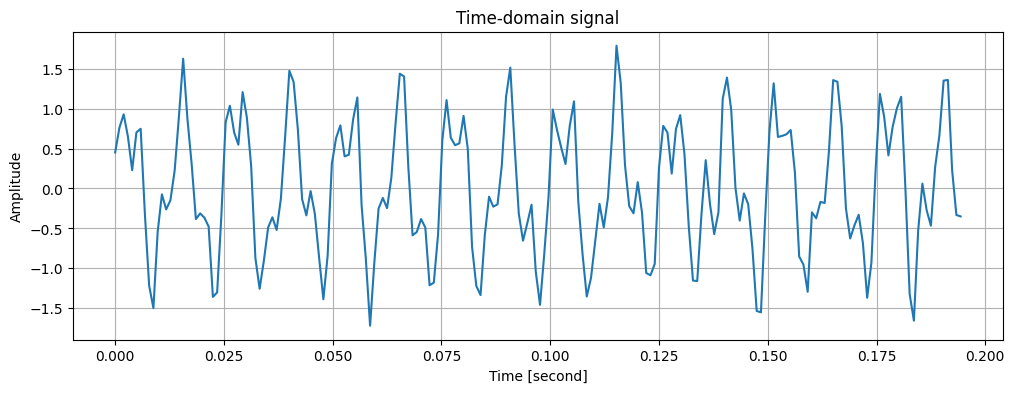

In [3]:
f1 = 80
f2 = 200

phase = np.pi / 4

x = (
    1.0 * np.sin(2 * np.pi * f1 * t)
    + 0.55 * np.sin(2 * np.pi * f2 * t + phase)
    + 0.20 * rng.normal(size=N)
)

plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])

plt.xlabel("Time [second]")
plt.ylabel("Amplitude")
plt.title("Time-domain signal")
plt.grid(True)
plt.show()

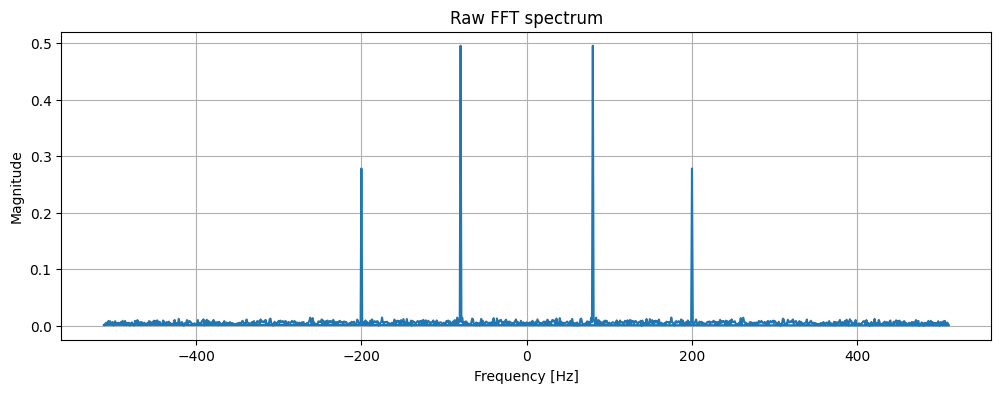

In [4]:
X = np.fft.fft(x)

frequency_axis = np.fft.fftfreq(
    N,
    d=1/fs
)

magnitude = np.abs(X) / N

plt.figure(figsize=(12, 4))
plt.plot(frequency_axis, magnitude)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Raw FFT spectrum")
plt.grid(True)
plt.show()

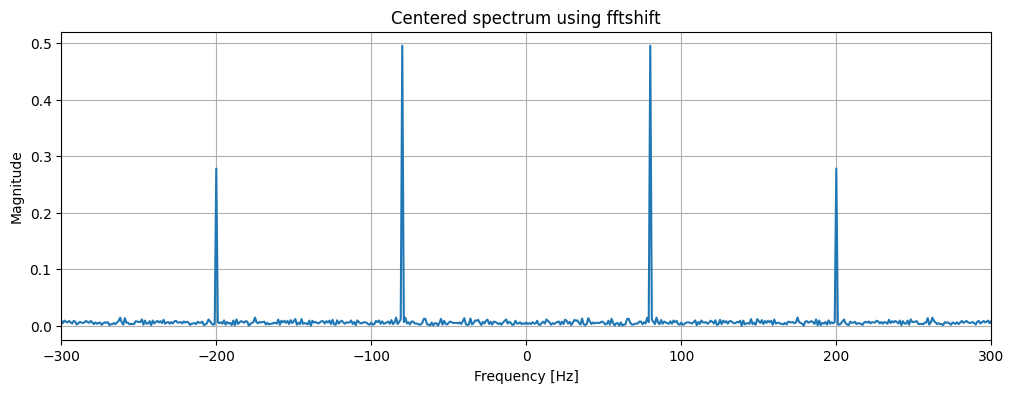

In [5]:
X_shifted = np.fft.fftshift(X)

frequency_shifted = np.fft.fftshift(
    frequency_axis
)

magnitude_shifted = np.abs(X_shifted) / N

plt.figure(figsize=(12, 4))
plt.plot(
    frequency_shifted,
    magnitude_shifted
)

plt.xlim(-300, 300)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Centered spectrum using fftshift")

plt.grid(True)
plt.show()

In [6]:
top_indices = np.argsort(magnitude_shifted)[-10:][::-1]
dominant_frequencies = frequency_shifted[top_indices]
dominant_magnitudes = magnitude_shifted[top_indices]
dominant_frequencies

array([  80.,  -80.,  200., -200.,  175., -175.,  -84.,   84.,  262.,
       -262.])

In [7]:
dominant_magnitudes

array([0.49504672, 0.49504672, 0.2780477 , 0.2780477 , 0.01468263,
       0.01468263, 0.01447315, 0.01447315, 0.01440947, 0.01440947])

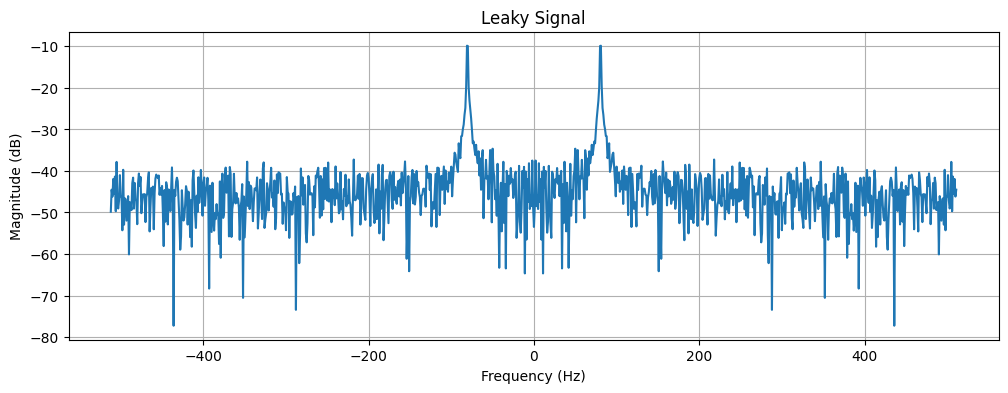

In [10]:
leaky_frequency=80.5 
x_leaky=np.sin(2 * np.pi * leaky_frequency * t) + 0.20 * rng.normal(size=N)
leaky_magnitude = np.abs(np.fft.fftshift(np.fft.fft(x_leaky))) / N
leaky_magnitude_db=20 * np.log10(leaky_magnitude + 1e-12)
plt.figure(figsize=(12, 4))
plt.plot(frequency_shifted, leaky_magnitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Leaky Signal")
plt.grid(True)
plt.show()

window function 

In [18]:
windows = {
    "Rectangular": signal.windows.boxcar(N),
    "Hann": signal.windows.hann(N),
    "Hamming": signal.windows.hamming(N),
    "Blackman": signal.windows.blackman(N),
    "Kaiser_beta_5": signal.windows.kaiser(N, beta=5),
    "Kaiser_beta_10": signal.windows.kaiser(N, beta=10),
}

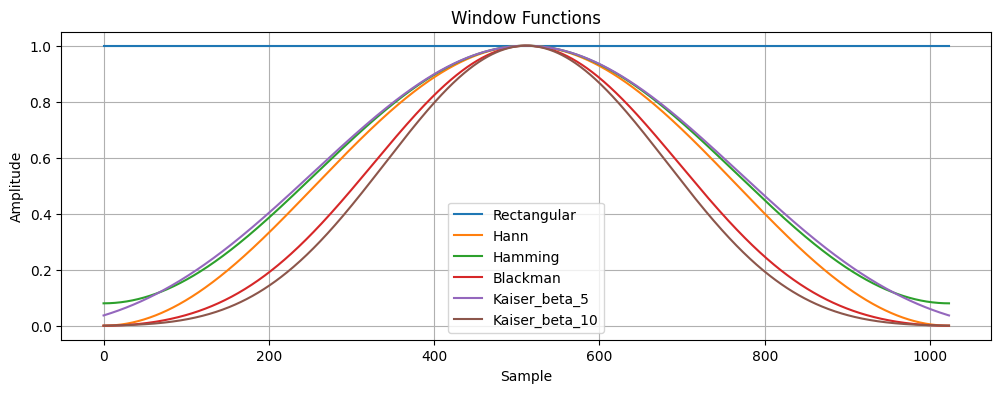

In [19]:
plt.figure(figsize=(12, 4))
for window_name, window in windows.items():
    plt.plot(window, label=window_name)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Window Functions")
plt.legend()
plt.grid(True)
plt.show()